In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import optuna 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
from sklearn.model_selection import learning_curve
from sklearn.metrics import roc_curve, precision_recall_curve, auc, precision_score, recall_score, f1_score, roc_auc_score
import optuna
#from utils.perm_class import ClassificationCV
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import shap
from PyALE import ale
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from scipy.stats.mstats import winsorize
from sklearn import set_config
import json
import joblib


Initialize

In [25]:
df = pd.read_csv('..\Data\loan_data_sample.csv')
features = ['loan_amnt', 'term', 'emp_length', 'home_ownership',
       'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs',
       'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'mths_since_last_major_derog',
       'application_type', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m',
       'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il',
       'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc',
       'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'chargeoff_within_12_mths', 'mo_sin_old_il_acct',
       'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
       'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq',
       'mths_since_recent_inq', 'mths_since_recent_revol_delinq',
       'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
       'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
       'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m',
       'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m',
       'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies',
       'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
       'total_il_high_credit_limit',
       'months_sincefrst_credit', 'public_record', 'is_consolidation',
       'addr_state', 'is_currently_delinq', 'has_il_history']

index_sql = 'Loan_ID'
target = 'predictor'

df_features  = df[features]
df_predictor = pd.Series(df[target])


#Imputing col's we imputed with 999 in SQL
imputed_cols = [
    'mths_since_last_delinq', 'mths_since_last_record', 
    'mths_since_last_major_derog', 'mths_since_recent_bc_dlq', 
    'mths_since_recent_inq', 'mths_since_recent_revol_delinq'
]

df_features.loc[:,imputed_cols] = df_features[imputed_cols].replace(999.0, np.nan)





X_train, X_test, y_train,y_test = train_test_split(df_features,df_predictor,stratify=df_predictor,test_size=.2,random_state=11)

categorical_features = X_train.select_dtypes(include=['object','category']).columns.tolist()
numerical_features = X_train.select_dtypes(include=['number']).columns.tolist()

In [36]:
print(X_train['home_ownership'].unique)

<bound method Series.unique of 38232         RENT
92062         RENT
81535     MORTGAGE
19865     MORTGAGE
99160         RENT
            ...   
78893          OWN
47965         RENT
34938          OWN
39457          OWN
114145    MORTGAGE
Name: home_ownership, Length: 104510, dtype: object>


Pipeline for Flags / missing values  --- Target Encoding

In [11]:


zero_cols = [
    'max_bal_bc', 'all_util', 'il_util', 'open_acc_6m',
    'open_il_12m', 'open_il_24m', 'open_rv_12m', 'open_rv_24m', 'inq_last_12m',
    'open_act_il', 'total_bal_il', 'total_il_high_credit_limit', 'is_consolidation'
]
flag_cols = [
    'mths_since_last_delinq', 'mths_since_last_record',
    'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq',
    'mths_since_recent_inq', 'mths_since_rcnt_il',
    'mths_since_last_major_derog'
]
median_cols = [
    'months_sincefrst_credit', 'annual_inc', 'inq_last_6mths',
    'revol_util', 'total_acc', 'pub_rec', 'open_acc',
    'mo_sin_old_rev_tl_op', 'num_rev_accts', 'tot_hi_cred_lim',
    'acc_open_past_24mths', 'num_bc_sats', 'num_sats', 'mort_acc',
    'mths_since_recent_bc', 'total_bc_limit', 'pub_rec_bankruptcies',
    'total_rev_hi_lim', 'inq_fi', 'avg_cur_bal', 'bc_open_to_buy',
    'bc_util', 'mo_sin_old_il_acct', 'mo_sin_rcnt_rev_tl_op',
    'mo_sin_rcnt_tl', 'num_accts_ever_120_pd', 'num_actv_bc_tl',
    'num_actv_rev_tl', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
    'num_rev_tl_bal_gt_0', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m',
    'pct_tl_nvr_dlq', 'percent_bc_gt_75',
    'total_cu_tl', 'total_bal_ex_mort', 'num_tl_30dpd',
    'num_tl_120dpd_2m', 'chargeoff_within_12_mths'
]

features_todrop = [
    'open_rv_12m', 'mths_since_last_delinq',
    'num_sats', 'open_act_il', 'il_util',
    'mths_since_rcnt_il',
    'mths_since_last_record', 'tax_liens',
    'total_bal_il', 'mths_since_recent_revol_delinq',
    'num_op_rev_tl', 'pub_rec', 'num_bc_tl',
    'mths_since_recent_inq', 'inq_fi',
    'public_record',
    'mths_since_recent_revol_delinq',
    'application_type_Joint App', 'pub_rec_bankruptcies',
    'num_accts_ever_120_pd',
    'mths_since_recent_bc_dlq',
    'home_ownership_OWN', 'has_il_history',
    'num_tl_90g_dpd_24m', 'chargeoff_within_12_mths',
    'num_tl_30dpd', 'num_tl_120dpd_2m',
    'is_currently_delinq', 'home_ownership_NONE',
    'home_ownership_OTHER'
]


numerical_features = ['loan_amnt', 'term', 'emp_length',
       'annual_inc', 'purpose', 'dti', 'delinq_2yrs',
       'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'mths_since_last_major_derog',
       'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m',
       'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il',
       'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc',
       'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'chargeoff_within_12_mths', 'mo_sin_old_il_acct',
       'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
       'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq',
       'mths_since_recent_inq', 'mths_since_recent_revol_delinq',
       'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
       'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
       'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m',
       'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m',
       'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies',
       'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
       'total_il_high_credit_limit',
       'months_sincefrst_credit', 'public_record', 'is_consolidation',
       'is_currently_delinq', 'has_il_history']

set_config(transform_output="pandas")


def fit_state_encoding(X_train, y_train, m=10):
    X_temp = X_train.copy()
    X_temp['predictor'] = y_train.values

    global_default_mean = y_train.mean()
    state_means  = X_temp.groupby('addr_state')['predictor'].mean()
    state_counts = X_temp['addr_state'].value_counts()

    means_smoothed = ((state_counts * state_means) + (m * global_default_mean)) / (state_counts + m)

    return means_smoothed, global_default_mean


def apply_state_encoding(X, means_smoothed, global_default_mean):
    X = X.copy()
    X['state_enc'] = X['addr_state'].map(means_smoothed).fillna(global_default_mean)
    return X



categorical_features = ['home_ownership', 'verification_status', 'application_type']

def apply_ohe(X):
    return pd.get_dummies(X[categorical_features], drop_first=True, dtype=int)



preprocessor = ColumnTransformer([
    ('zeros',  SimpleImputer(strategy='constant', fill_value=0), zero_cols),
    ('flags',  SimpleImputer(strategy='median', add_indicator=True), flag_cols),
    ('median', SimpleImputer(strategy='median'), median_cols)
], remainder='passthrough')



def add_features(X):
    eps = 0.001
    X = X.copy()

    X['FE_loan_to_income'] = X['remainder__loan_amnt'] / (X['median__annual_inc'] + eps)
    X['FE_free_cash_flow'] = (X['median__annual_inc'] / 12) * (1 - (X['remainder__dti'] / 100))
    X['FE_activity_ratio'] = X['median__num_actv_rev_tl'] / (X['median__num_op_rev_tl'] + eps)

    return X



def preprocess_train(X_train, y_train, numerical_features):

    means_smoothed, global_default_mean = fit_state_encoding(X_train, y_train)
    X_train = apply_state_encoding(X_train, means_smoothed, global_default_mean)

    X_encoded = apply_ohe(X_train)

    X_train_full = pd.concat([X_train[numerical_features], X_encoded], axis=1)

    train_columns_before_impute = X_train_full.columns.tolist()

    X_train_processed = preprocessor.fit_transform(X_train_full)

    X_train_processed = add_features(X_train_processed)

    upperbounds = X_train_processed.quantile(0.99)
    lowerbounds = X_train_processed.quantile(0.01)
    X_train_processed = X_train_processed.clip(lower=lowerbounds, upper=upperbounds, axis=1)

    X_train_processed = X_train_processed.drop(
        columns=[c for c in features_todrop if c in X_train_processed.columns]
    )

    return (
        X_train_processed,
        means_smoothed,
        global_default_mean,
        upperbounds,
        lowerbounds,
        train_columns_before_impute
    )



def preprocess_test(X_test,means_smoothed,global_default_mean,
    upperbounds,lowerbounds,numerical_features,train_columns_before_impute):

    X_test = apply_state_encoding(X_test, means_smoothed, global_default_mean)
    X_encoded_test = apply_ohe(X_test)
    X_test_full = pd.concat([X_test[numerical_features], X_encoded_test], axis=1)
    X_test_full = X_test_full.reindex(columns=train_columns_before_impute, fill_value=0)
    X_test_processed = preprocessor.transform(X_test_full)
    X_test_processed = add_features(X_test_processed)
    X_test_processed = X_test_processed.clip(lower=lowerbounds, upper=upperbounds, axis=1)
    X_test_processed = X_test_processed.drop(columns=[c for c in features_todrop if c in X_test_processed.columns])

    return X_test_processed




In [11]:
with open('../models/Trees/features_todrop.json', 'w') as f:
    json.dump(features_todrop, f)

Saving model components

In [12]:
X_train_pre, means_smoothed, global_default_mean, upperbounds, lowerbounds, train_columns_before_impute = preprocess_train(
    X_train.copy(), y_train, numerical_features
)

X_test_pre = preprocess_test(
    X_test.copy(),
    means_smoothed,
    global_default_mean,
    upperbounds,
    lowerbounds,
    numerical_features,
    train_columns_before_impute
)


In [ ]:
joblib.dump(train_columns_before_impute, '../models/Trees/train_columns.pkl')
joblib.dump(preprocessor,        '../models/Trees/preprocessor.pkl')
joblib.dump(means_smoothed,      '../models/Trees/state_means.pkl')
joblib.dump(global_default_mean, '../models/Trees/global_default_mean.pkl')
joblib.dump(upperbounds,         '../models/Trees/upperbounds.pkl')
joblib.dump(lowerbounds,         '../models/Trees/lowerbounds.pkl')

with open('../models/Trees/train_columns_before_impute.json', 'w') as f:
    json.dump(train_columns_before_impute, f)

with open('../models/Trees/numerical_features.json', 'w') as f:
    json.dump(numerical_features, f)

with open('../models/Trees/categorical_features.json', 'w') as f:
    json.dump(categorical_features, f)

Hypertune our Catboost (Highest AUC) using optuna:

In [13]:
def objective_cat(trial):
    # 1. Your excellent parameter ranges
    params = {
        "iterations": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 50),
        "loss_function": "Logloss",
        "eval_metric": "AUC",          
        "random_seed": 11,              
        "verbose": 0,
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)
    auc_scores = []

    
    for train_idx, val_idx in cv.split(X_train_pre, y_train):
        X_tr, y_tr = X_train_pre.iloc[train_idx], y_train.iloc[train_idx]
        X_val, y_val = X_train_pre.iloc[val_idx], y_train.iloc[val_idx]

        model = CatBoostClassifier(**params)
        
        
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            early_stopping_rounds=50,
            verbose=0
        )

        
        preds = model.predict_proba(X_val)[:, 1]
        fold_auc = roc_auc_score(y_val, preds)
        auc_scores.append(fold_auc)

    return np.mean(auc_scores)


study_cat = optuna.create_study(direction="maximize")
study_cat.optimize(objective_cat, n_trials=50, timeout=600)

print("Best AUC:", study_cat.best_value)
print("Best params:")
for k, v in study_cat.best_params.items():
    print(f"  {k}: {v}")

[I 2026-03-27 19:24:55,581] A new study created in memory with name: no-name-4639c162-6e37-4793-a1d5-b77969aa7eb0
[I 2026-03-27 19:25:47,341] Trial 0 finished with value: 0.7140518071651668 and parameters: {'learning_rate': 0.26420818986155176, 'depth': 7, 'l2_leaf_reg': 3.698741705483208, 'subsample': 0.6596169215332629, 'colsample_bylevel': 0.8670559804030575, 'min_data_in_leaf': 17}. Best is trial 0 with value: 0.7140518071651668.
[I 2026-03-27 19:28:36,035] Trial 1 finished with value: 0.7162338452732702 and parameters: {'learning_rate': 0.013583520868958232, 'depth': 4, 'l2_leaf_reg': 7.56304954815371, 'subsample': 0.7827561035734089, 'colsample_bylevel': 0.6570541148899505, 'min_data_in_leaf': 29}. Best is trial 1 with value: 0.7162338452732702.
[I 2026-03-27 19:33:26,294] Trial 2 finished with value: 0.718313139988785 and parameters: {'learning_rate': 0.046991805359841585, 'depth': 10, 'l2_leaf_reg': 3.6398375009604247, 'subsample': 0.6517506539601077, 'colsample_bylevel': 0.522

Best AUC: 0.721888150942163
Best params:
  learning_rate: 0.04858069964969756
  depth: 7
  l2_leaf_reg: 7.965366676556213
  subsample: 0.7880756225427407
  colsample_bylevel: 0.7282769906900555
  min_data_in_leaf: 27


In [ ]:
#best_params = study_cat.best_params
best_params = {
    'learning_rate': 0.04349677214331854,
    'depth': 5,
    'l2_leaf_reg': 4.409109709781183,
    'subsample': 0.6885334061544024,
    'colsample_bylevel': 0.795976852867045,
    'min_data_in_leaf': 47,
    "iterations": 1000,
    "loss_function": "Logloss",
    "eval_metric": "AUC"
}

tuned_model = CatBoostClassifier(**best_params,verbose=0,random_state=11)
tuned_model.fit(X_train_pre,y_train)
#tuned_model.save_model('../models/Trees/catboost_tuned.cbm')


Learning Curve

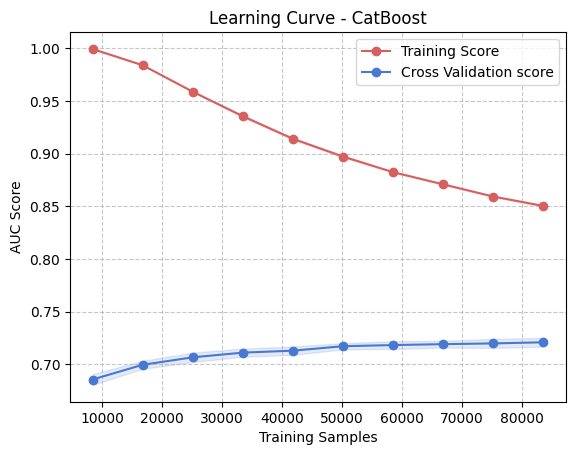

In [ ]:
def plot_learning_curve(estimator,X,y,model_name='CatBoost'):
    train_sizes,train_scores,test_scores = learning_curve(
        estimator,X,y,cv=5,n_jobs=-1,
        train_sizes=np.linspace(0.1,1,10),
        scoring='roc_auc'
    )
    train_mean = np.mean(train_scores,axis=1)
    train_std = np.std(train_scores,axis=1)
    test_mean = np.mean(test_scores,axis=1)
    test_std = np.std(test_scores,axis=1)

    plt.plot(train_sizes,train_mean,label='Training Score',color='#d65f5f',marker='o')
    plt.fill_between(train_sizes,train_mean - train_std,train_mean+train_std,alpha=0.15,color='#d65f5f')

    plt.plot(train_sizes,test_mean,label='Cross Validation score',color='#4878d0', marker='o')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='#4878d0')

    plt.title(f"Learning Curve - {model_name}")
    plt.xlabel('Training Samples')
    plt.ylabel('AUC Score')
    plt.legend()
    plt.grid(True,linestyle='--', alpha=0.7)
    #plt.savefig(f'LearningCurve_{model_name}.png',dpi=300,bbox_inches='tight')
    plt.show()


tuned_model = CatBoostClassifier(**best_params,verbose=0,random_state=11)


plot_learning_curve(tuned_model,X_train_pre,y_train,model_name='CatBoost')

Optimizing Threshold for maximum Net value

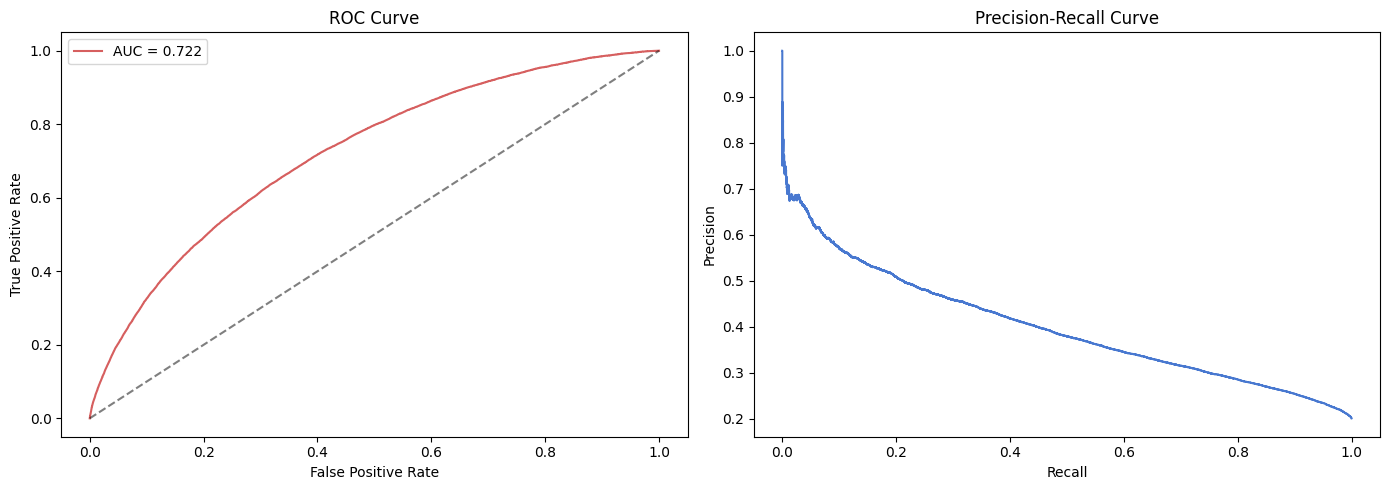

In [14]:
best_params = {
    'learning_rate': 0.04349677214331854,
    'depth': 5,
    'l2_leaf_reg': 4.409109709781183,
    'subsample': 0.6885334061544024,
    'colsample_bylevel': 0.795976852867045,
    'min_data_in_leaf': 47,
    "iterations": 1000,
    "loss_function": "Logloss",
    "eval_metric": "AUC"
}

tuned_model = CatBoostClassifier(**best_params,verbose=0,random_state=11)
tuned_model.fit(X_train_pre,y_train)
y_pred_proba = cross_val_predict(
    CatBoostClassifier(**best_params, verbose=0, random_seed=11),
    X_train_pre, y_train,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=11),
    method='predict_proba',
    n_jobs=-1
)[:, 1]

fpr, tpr, roc_thresholds = roc_curve(y_train, y_pred_proba)
roc_auc = auc(fpr, tpr)

precision, recall, pr_thresholds = precision_recall_curve(y_train, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color='#d65f5f', label=f'AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

axes[1].plot(recall, precision, color='#4878d0')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
#plt.savefig('Images_trees/roc_prc.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# F1 score at each threshold — balances precision and recall


denom = precision[:-1] + recall[:-1]
f1_scores = np.where(denom == 0, 0, 2 * (precision[:-1] * recall[:-1]) / denom)
best_threshold = pr_thresholds[np.argmax(f1_scores)]
print(f"Best threshold by F1: {best_threshold:.3f}")

Best threshold by F1: 0.213


Expected net values:

In [16]:
thresholds_to_check = [0.190, 0.213, 0.250, 0.300, 0.350, 0.400, 0.500]

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)

for i in thresholds_to_check:
    preds = (y_pred_proba >= i).astype(int)
    p = precision_score(y_train, preds)
    r = recall_score(y_train, preds)
    f = f1_score(y_train, preds)
    print(f"{i:<12.3f} {p:<12.3f} {r:<12.3f} {f:<12.3f}")

Threshold    Precision    Recall       F1          
------------------------------------------------
0.190        0.320        0.683        0.436       
0.213        0.340        0.619        0.439       
0.250        0.372        0.523        0.435       
0.300        0.416        0.407        0.411       
0.350        0.457        0.305        0.366       
0.400        0.494        0.222        0.307       
0.500        0.568        0.103        0.174       


In [17]:
avg_loan = X_train_pre['remainder__loan_amnt'].mean()
avg_interest_rate = 0.130929128970242  # Got this from SQL, it would have been Data Leakage otherwise to include as a feature! :P
loss_given_default = 0.6 #this is assumed and not from model
interest_revenue = avg_loan * avg_interest_rate  # revenue from good loans

print(f"Avg loan: ${avg_loan:,.0f}")
print(f"Avg interest rate: {avg_interest_rate:.3f}")
print(f"Estimated interest revenue per good loan: ${interest_revenue:,.0f}")

print(f"\n{'Threshold':<12} {'Expected Loss':<20} {'Expected Gain':<20} {'Net Value':<20}")
print("-" * 72)

for i in thresholds_to_check:
    preds = (y_pred_proba >= i).astype(int)
    
    tp = ((preds == 1) & (y_train == 1)).sum() 
    fp = ((preds == 1) & (y_train == 0)).sum()  
    tn = ((preds == 0) & (y_train == 0)).sum()  
    fn = ((preds == 0) & (y_train == 1)).sum()  

    loss = (fn * avg_loan * loss_given_default) + (fp * interest_revenue)
    gain = (tn * interest_revenue) + (tp * avg_loan * loss_given_default)  
    net = gain - loss
    
    print(f"{i:<12.3f} ${loss:<19,.0f} ${gain:<19,.0f} ${net:<19,.0f}")

Avg loan: $14,371
Avg interest rate: 0.131
Estimated interest revenue per good loan: $1,882

Threshold    Expected Loss        Expected Gain        Net Value           
------------------------------------------------------------------------
0.190        $114,761,617         $223,403,752         $108,642,135        
0.213        $116,406,065         $221,759,305         $105,353,240        
0.250        $121,178,916         $216,986,453         $95,807,537         
0.300        $129,999,516         $208,165,853         $78,166,337         
0.350        $140,098,572         $198,066,797         $57,968,224         
0.400        $149,757,706         $188,407,663         $38,649,957         
0.500        $165,507,325         $172,658,045         $7,150,720          


In [18]:
for i in thresholds_to_check:
    flagged = (y_pred_proba >= i).sum()
    pct = flagged / len(y_pred_proba) * 100
    print(f"Threshold {i} | Flagged: {flagged:,} ({pct:.1f}% of applicants)")

Threshold 0.19 | Flagged: 44,780 (42.8% of applicants)
Threshold 0.213 | Flagged: 38,257 (36.6% of applicants)
Threshold 0.25 | Flagged: 29,500 (28.2% of applicants)
Threshold 0.3 | Flagged: 20,544 (19.7% of applicants)
Threshold 0.35 | Flagged: 14,026 (13.4% of applicants)
Threshold 0.4 | Flagged: 9,457 (9.0% of applicants)
Threshold 0.5 | Flagged: 3,804 (3.6% of applicants)


Confusion Matrix

## Finding our ineffective features

In [ ]:
shp_explainer = shap.TreeExplainer(tuned_model)

#we'll take a sample of X_train

X_train_sample, null, y_train_sample, null1 = train_test_split(X_train_pre,y_train,train_size=5000,
                                                               stratify=y_train,random_state=11)
 
shap_values = shp_explainer(X_train_sample)

In [ ]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

shap_imprtnce_df = pd.DataFrame({
    'Feature':X_train_sample.columns,
    'Mean Absolute SHAP': mean_abs_shap
})

shap_imprtnce_df = shap_imprtnce_df.sort_values(by='Mean Absolute SHAP',ascending=False).reset_index(drop=True)
print(f' the Top 15 features are \n')
print(shap_imprtnce_df.head(15),'\n')
print(f'Bottom 30 features are \n')
print(shap_imprtnce_df.tail(30))
features_todrop=shap_imprtnce_df[shap_imprtnce_df['Mean Absolute SHAP']< 0.005]['Feature'].tolist()
print(f'Amount of features to drop: {len(features_todrop)}')
#We're going to take these features and drop them 
print(features_todrop)

Bar plot 

In [ ]:
plt.figure(figsize=(10, 8))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("Global Feature Importance, Mean Absolute SHAP Value", fontsize=13)
plt.tight_layout()
plt.savefig('Images_trees/SHAP_bar.png', dpi=300, bbox_inches='tight')
plt.show()

Dendrogram - Showing correlated features

In [ ]:
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform

slim_features =shap_imprtnce_df[shap_imprtnce_df['Mean Absolute SHAP']> 0.04]['Feature'].tolist()
X_train_slim = X_train_pre[slim_features]
corr_matrix = X_train_slim.corr(method='spearman')


dist_matrix = 1 - np.abs(corr_matrix.values)

condensed_dist = squareform(dist_matrix, checks=False)

clustering = sch.linkage(condensed_dist, method="complete")

plt.figure(figsize=(14, 8))
plt.title("Feature Redundancy", fontsize=16)

dend = sch.dendrogram(
    clustering, 
    labels=X_train_slim.columns,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.ylabel("Distance (1 - |Correlation|)", fontsize=12)
plt.axhline(y=0.2, color='r', linestyle='--') # 80% correlation
plt.tight_layout()
plt.savefig('Images_trees/dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

##### Shap plots 

In [ ]:
plt.figure(figsize=(20, 14))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("Global Feature Impact (Top 15 Features)", fontsize=14)
plt.tight_layout()
plt.savefig('Images_trees/Global_featureImpact.png',dpi=300,bbox_inches='tight')
plt.show()

Interaction terms

In [ ]:
X_interaction_sample = X_train_sample.sample(1000, random_state=11)
shap_interaction_values = shp_explainer.shap_interaction_values(X_interaction_sample)

# Plot top interaction
shap.summary_plot(shap_interaction_values, X_interaction_sample, max_display=10)

## Test data verification

In [19]:
best_params = {
    'learning_rate': 0.04349677214331854,
    'depth': 5,
    'l2_leaf_reg': 4.409109709781183,
    'subsample': 0.6885334061544024,
    'colsample_bylevel': 0.795976852867045,
    'min_data_in_leaf': 47,
    "iterations": 1000,
    "loss_function": "Logloss",
    "eval_metric": "AUC"
}

tuned_model = CatBoostClassifier(**best_params,verbose=0,random_state=11)
tuned_model.fit(X_train_pre,y_train)
y_test_proba = tuned_model.predict_proba(X_test_pre)[:,1]
y_test_pred = (y_test_proba >= .213).astype(int)

test_auc = roc_auc_score(y_test,y_test_proba)
print(f"Test AUC: {test_auc:.3f}")
print(f"Train AUC (CV): 0.722")
print(f"Difference: {abs(test_auc - 0.722):.3f}")

Test AUC: 0.720
Train AUC (CV): 0.721
Difference: 0.001


Expected Value on X_test

In [21]:
avg_loan = X_test_pre['remainder__loan_amnt'].mean()
avg_interest_rate = 0.130929128970242
interest_revenue = avg_loan * avg_interest_rate
loss_given_default = 0.6


thresholds_to_check=[0.190,0.213,0.3,0.4,0.5]

print(f"Avg loan: ${avg_loan:,.0f}")
print(f"Avg interest rate: {avg_interest_rate:.3f}")
print(f"Estimated interest revenue per good loan: ${interest_revenue:,.0f}")

print(f"\n{'Threshold':<12} {'Expected Loss':<20} {'Expected Gain':<20} {'Net Value':<20}")
print("-" * 72)

for i in thresholds_to_check:
    preds = (y_test_proba >= i).astype(int)
    
    tp = ((preds == 1) & (y_test == 1)).sum() 
    fp = ((preds == 1) & (y_test == 0)).sum()  
    tn = ((preds == 0) & (y_test == 0)).sum()  
    fn = ((preds == 0) & (y_test == 1)).sum()  

    loss = (fn * avg_loan * loss_given_default) + (fp * interest_revenue)
    gain = (tn * interest_revenue) + (tp * avg_loan * loss_given_default)  
    net = gain - loss
    
    print(f"{i:<12.3f} ${loss:<19,.0f} ${gain:<19,.0f} ${net:<19,.0f}")


Avg loan: $14,460
Avg interest rate: 0.131
Estimated interest revenue per good loan: $1,893

Threshold    Expected Loss        Expected Gain        Net Value           
------------------------------------------------------------------------
0.190        $28,889,010          $56,181,905          $27,292,895         
0.213        $29,212,642          $55,858,272          $26,645,630         
0.300        $33,222,599          $51,848,316          $18,625,717         
0.400        $37,879,912          $47,191,002          $9,311,090          
0.500        $41,870,253          $43,200,661          $1,330,408          


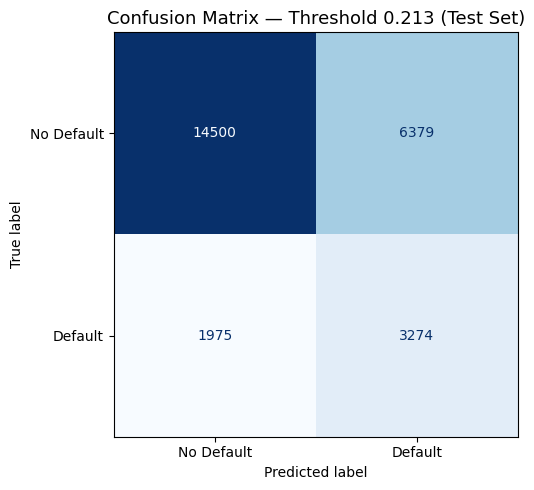

True Negatives: 14,500
False Positives:     6,379
False Negatives:   1,975
True Positives:   3,274

               precision    recall  f1-score   support

  No Default       0.88      0.69      0.78     20879
     Default       0.34      0.62      0.44      5249

    accuracy                           0.68     26128
   macro avg       0.61      0.66      0.61     26128
weighted avg       0.77      0.68      0.71     26128



In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

threshold = 0.213
y_test_pred = (y_test_proba >= threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — Threshold {threshold} (Test Set)', fontsize=13)
plt.tight_layout()
#plt.savefig('Images_trees/ConfusionMatrix_test.png', dpi=300, bbox_inches='tight')
plt.show()

# Readable summary
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn:,}")
print(f"False Positives:     {fp:,}")
print(f"False Negatives:   {fn:,}")
print(f"True Positives:   {tp:,}")

# Full classification report
print("\n", classification_report(y_test, y_test_pred, target_names=['No Default', 'Default']))

### Error Analysis on Test data

In [ ]:
X_test_sample = X_test.sample(2000).index

y_test_sample = y_test.loc[X_test_sample]
y_test_pred_sample = y_test_pred[X_test_sample] 

fp = (y_test_pred_sample==0) & (y_test_sample == 1)
fn = (y_test_pred_sample==1) & (y_test_sample == 0)

explainer = shap.TreeExplainer(tuned_model)
shap_values = explainer(X_test_sample)


shap_values_fp = shap_values[fp]

shap_values_fn = shap_values[fn]

fig = plt.figure(figsize=(12,10))
ax1 = fig.add_subplot(211)
plt.title(f"False Positives", fontsize=14)
shap.plots.bar(shap_values_fp, max_display=10, show=False) 

ax2 = fig.add_subplot(212)
plt.title(f"False Negatives", fontsize=14)
shap.plots.bar(shap_values_fn, max_display=10, show=False)

plt.tight_layout()
plt.show()